<a href="https://colab.research.google.com/github/RiteeshTM/Financial-Market-Trend-Risk-Analysis-Business-Analytics-Project-/blob/main/BusinessAnalyticsProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [5]:
data = yf.download("RELIANCE.NS", start="2018-01-01")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.tail()

/tmp/ipykernel_651/941683073.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("RELIANCE.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440
2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722
2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007
2026-03-05,1389.400024,1399.000000,1353.099976,1353.099976,25957532
2026-03-06,1404.800049,1424.300049,1390.300049,1396.500000,19311019


In [6]:
data["simple_return"] = data["Close"].pct_change()

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

data = data.dropna()
data

Price,Close,High,Low,Open,Volume,simple_return,log_return
Date,,,,,,,
2018-01-02,402.483215,406.193768,400.384994,403.300424,9499419,0.001539,0.001538
2018-01-03,404.095490,409.042883,403.322453,408.601135,13507800,0.004006,0.003998
2018-01-04,406.525085,407.187693,404.493122,405.575361,9008932,0.006012,0.005994
2018-01-05,407.828156,409.440487,406.502971,407.187664,7441284,0.003205,0.003200
2018-01-08,410.169312,411.251551,407.938575,409.087072,8827020,0.005741,0.005724
...,...,...,...,...,...,...,...
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440,-0.009170,-0.009212
2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722,-0.025755,-0.026093
2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007,-0.009573,-0.009619


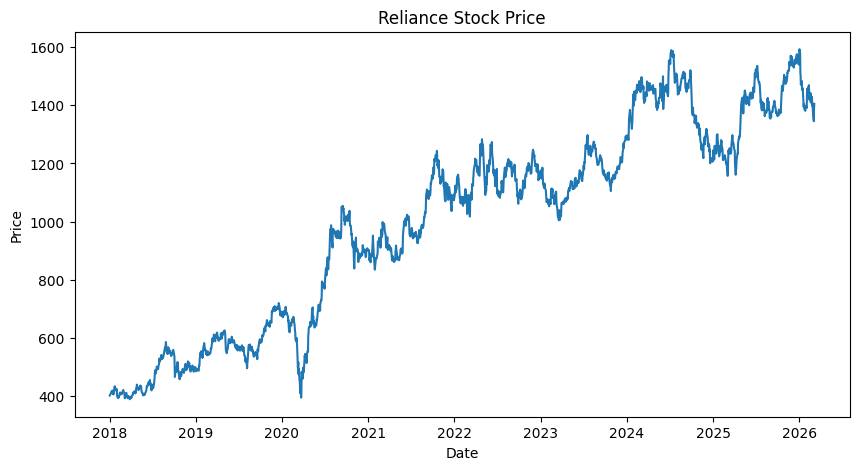

In [7]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data["Close"])
plt.title("Reliance Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Volatility Analysis

In [8]:
daily_volatility = data["log_return"].std()
annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annual Volatility:", annual_volatility)

Daily Volatility: 0.017498574242563406
Annual Volatility: 0.27778125446413926


## Sharpe Ratio

In [9]:
annual_return = data["log_return"].mean() * 252

risk_free_rate = 0.07  # Approx Indian risk-free rate

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Annual Return:", annual_return)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.15613202053448302
Sharpe Ratio: 0.310071393048599


## Beta Calculation (Market Risk)

In [10]:
# Download NIFTY data
market = yf.download("^NSEI", start="2018-01-01")

if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

data.index = data.index.tz_localize(None)
market.index = market.index.tz_localize(None)

market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

df = pd.concat(
    [data["log_return"], market["market_return"]],
    axis=1
).dropna()

# Regression
X = sm.add_constant(df["market_return"])
y = df["log_return"]

model = sm.OLS(y, X).fit()

beta = model.params[1]

print("Beta:", beta)

/tmp/ipykernel_651/2706225358.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed

Beta: 1.1157036614712421



/tmp/ipykernel_651/2706225358.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


##  Value at Risk (VaR)

In [11]:
VaR_95 = np.percentile(data["log_return"], 5)

print("95% Value at Risk:", VaR_95)

95% Value at Risk: -0.023577139390673782


## Stationarity Test (ADF)

In [12]:
result = adfuller(data["log_return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.475951827318017
p-value: 3.3119587956842406e-25


## ARIMA Model

In [13]:
model = ARIMA(data["log_return"], order=(1,0,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2020
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5307.179
Date:                Fri, 06 Mar 2026   AIC                         -10606.359
Time:                        18:19:47   BIC                         -10583.915
Sample:                             0   HQIC                        -10598.122
                               - 2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.577      0.115      -0.000       0.001
ar.L1         -0.6060      0.280     -2.167      0.030      -1.154      -0.058
ma.L1          0.5841      0.284      2.057      0.0

## Forecast Future Returns

In [14]:
forecast = model_fit.forecast(steps=5)

print("Next 5 day forecast:")
print(forecast)

Next 5 day forecast:
2020    0.000813
2021    0.000499
2022    0.000689
2023    0.000574
2024    0.000644
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Return Distribution

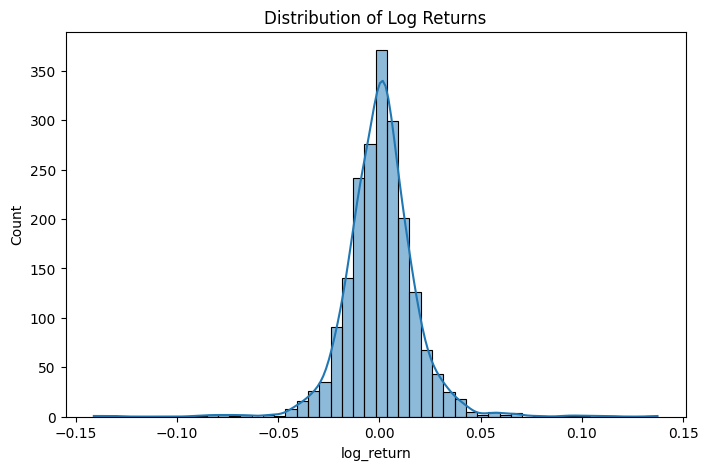

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data["log_return"], bins=50, kde=True)
plt.title("Distribution of Log Returns")
plt.show()